## XGBRegressor Regression Exercise

![Namespace Labs](../../../../labs.png)

## Predict the price

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
df = pd.read_csv('autos.csv')

In [3]:
df.head()

,symboling,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,13495
1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,16500
2,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154.0,5000,19,26,16500
3,2,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102.0,5500,24,30,13950
4,2,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115.0,5500,18,22,17450


In [4]:
# Print the head of the dataset


In [5]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329171,3.255317,10.142537,104.256098,5125.365854,25.219512,30.751220,13207.126829
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270875,0.313598,3.972040,39.519211,476.979095,6.542142,6.886443,7868.768212
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10595.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [6]:
# Describe the dataset


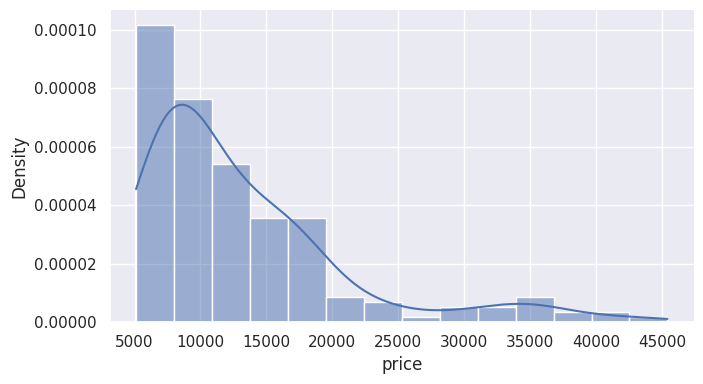

In [7]:
sns.displot(data=df, x='price', kind='hist', stat='density', kde=True, height=4, aspect=1.8)

In [8]:
# Plot a distribution of the price


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   make               205 non-null    object 
 2   fuel-type          205 non-null    object 
 3   aspiration         205 non-null    object 
 4   num-of-doors       205 non-null    object 
 5   body-style         205 non-null    object 
 6   drive-wheels       205 non-null    object 
 7   engine-location    205 non-null    object 
 8   wheel-base         205 non-null    float64
 9   length             205 non-null    float64
 10  width              205 non-null    float64
 11  height             205 non-null    float64
 12  curb-weight        205 non-null    int64  
 13  engine-type        205 non-null    object 
 14  num-of-cylinders   205 non-null    object 
 15  engine-size        205 non-null    int64  
 16  fuel-system        205 non

In [10]:
# Create a variable of the categorical features
cats = df.select_dtypes(include='O').columns
cats

Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system'],
      dtype='object')

In [11]:
# Create dummy variables
# Name the new dataframe auto
auto = pd.get_dummies(data=df, columns=cats, drop_first=True)

In [12]:
# Create the X variable
X = auto.drop('price', axis=1)

In [13]:
# Create the y variable
y = auto.price

In [14]:
# Import train_test_split
from sklearn.model_selection import train_test_split

In [47]:
# Split the dataset into a training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [48]:
# Import the XGBRegressor
from xgboost import XGBRegressor

In [49]:
# Create an instance of XGBRegressor
model = XGBRegressor()

In [50]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [51]:
# Fit the dataset to the model


In [52]:
# Make predictions
# Save them in a predictions dataframe
predictions = model.predict(X_test)

In [53]:
# Import the regression metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [54]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

In [55]:
# Print the metrics
print(f'The Mean Absolute Error is {mae}')
print(f'The Mean Squarred Error is {mse}')
print(f'Root Mean Squared Error is {rmse}')

The Mean Absolute Error is 1644.55078125
The Mean Squarred Error is 6231429.0
Root Mean Squared Error is 2496.282958984375


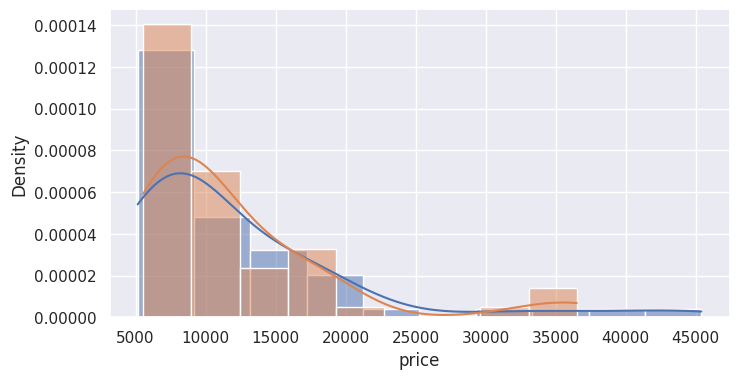

In [56]:
plt.figure(figsize=(8,4))
sns.histplot(y_test,  stat='density', kde=True)
sns.histplot(predictions, stat='density', kde=True)
plt.show()

In [57]:
# Plot the distribution plot of the 
# Predicted price and the real price


<Axes: xlabel='price', ylabel='Count'>

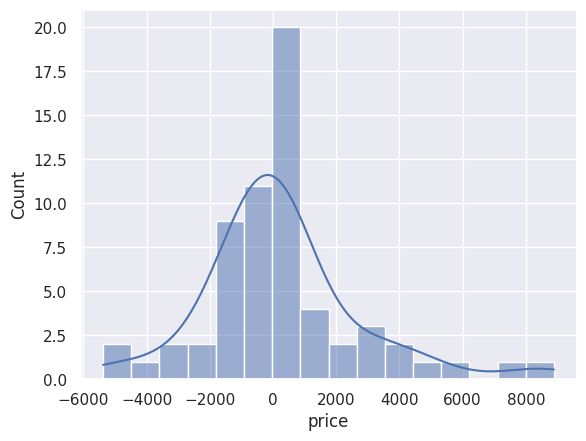

In [58]:
# Plot a distribution of the differences between
# the true values and the predicted values
sns.histplot(y_test - predictions, kde=True)


<Axes: xlabel='price'>

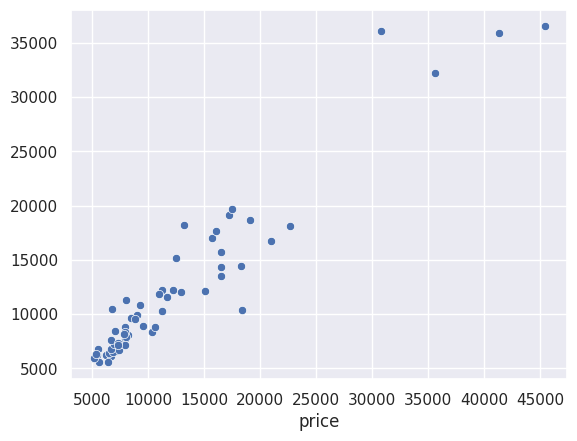

In [59]:
# Plot the scatterplot of the predictions
# And the true values
sns.scatterplot(x=y_test, y=predictions)

In [60]:
# Create a dataframe of the importances
importances = pd.DataFrame({'Feature':X.columns, 'Importance':model.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=False).head(10)

<Axes: xlabel='Importance', ylabel='Feature'>

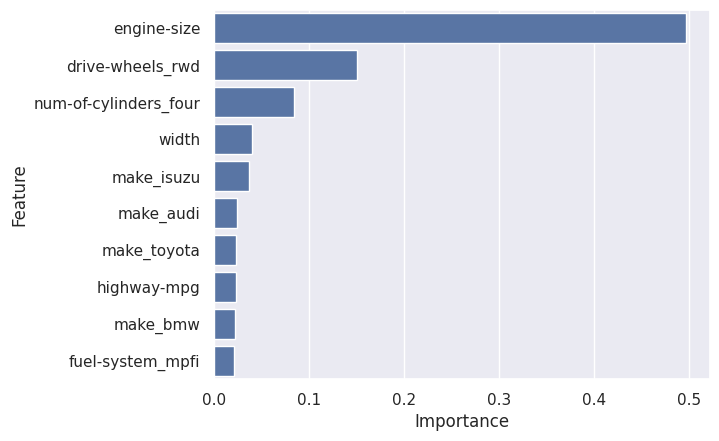

In [61]:
# Plot the importances
sns.barplot(data=importances, y='Feature', x='Importance')

Happy coding!